In [1]:
import pandas as pd
gsl_monthly_df = pd.read_csv('gsl_monthly_df.csv')
gsl_monthly_df.head()

,date,year,month,elevation_ft,monthly_precip_in,snow_water_equiv_in,volume_acft,SA_ac,SA_prior_month_ac,prior_month_vol_acft,precip_acft,total_inflow_cfs_acft,evaporation_acft,bear_river_acft,weber_river_acft,jordan_river_surplus_acft,jordan_river_1700_acft
0,1950-02-01,1950,2,4197.40,1.19,NaN,13231625.08,879251.73,864498.36,13013628.81,85729.420700,330234.8985,197968.049200,144101.275,36621.3605,11994.2245,7142.5835
1,1950-03-01,1950,3,4197.90,0.98,NaN,13677742.99,905185.46,879251.73,13231625.08,71805.557950,378388.3280,4075.975950,161080.035,60738.7370,11591.5740,7025.5570
2,1950-04-01,1950,4,4198.15,1.29,NaN,13905660.50,918138.01,905185.46,13677742.99,97307.436950,607916.9645,477306.891450,228618.210,144858.9720,11311.9005,7144.5670
3,1950-05-01,1950,5,4198.35,2.18,NaN,14090506.69,928507.42,918138.01,13905660.50,166795.071817,811463.7345,793412.616317,288876.940,230403.3600,14786.9925,7263.5770
4,1950-06-01,1950,6,4198.80,0.16,NaN,14513327.20,951733.99,928507.42,14090506.69,12380.098933,571448.3335,161007.922433,220446.190,123647.4230,15227.3295,7688.0460


In [2]:
# creating new dataframe with selected features for the non-snowpack model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

gsl_monthly_df = pd.read_csv('gsl_monthly_df.csv')

gsl_monthly_df['date'] = pd.to_datetime(gsl_monthly_df['date'])
gsl_monthly_df = gsl_monthly_df.sort_values('date').reset_index(drop=True)

# selecting desired features (excluding snowpack)
features = [
    'elevation_ft',
    'total_inflow_cfs_acft',
    'precip_acft',
    'evaporation_acft'
]

# making sure there are no missing values in the selected features
print(gsl_monthly_df[features].isna().sum())

gsl_monthly_nosnow = gsl_monthly_df[['date', 'year', 'month'] + features]

# filtering for complete years (12 months of data)
month_counts = gsl_monthly_nosnow.groupby('year')['month'].count()
complete_years = month_counts[month_counts == 12].index
gsl_monthly_nosnow = gsl_monthly_nosnow[gsl_monthly_nosnow['year'].isin(complete_years)].reset_index(drop=True)

# assessing complete years available
print(f"Complete years available: {len(complete_years)}")
print(f"First year: {complete_years.min()}, Last year: {complete_years.max()}")

# sorting by year and month so rows are always jan to dec for each year
gsl_monthly_nosnow = gsl_monthly_nosnow.sort_values(['year', 'month'])
gsl_monthly_nosnow.tail(20)


elevation_ft             0
total_inflow_cfs_acft    0
precip_acft              0
evaporation_acft         0
dtype: int64
Complete years available: 74
First year: 1951, Last year: 2024


,date,year,month,elevation_ft,total_inflow_cfs_acft,precip_acft,evaporation_acft
868,2023-05-01,2023,5,4193.15,1.076516e+06,28152.194633,362132.445253
869,2023-06-01,2023,6,4193.84,4.515186e+05,22014.037825,-1014.987625
870,2023-07-01,2023,7,4193.51,7.518358e+04,3499.560300,307335.956050
871,2023-08-01,2023,8,4192.88,9.369300e+04,157634.267083,679201.899783
872,2023-09-01,2023,9,4192.34,1.078542e+05,50871.873325,516986.674275
873,2023-10-01,2023,10,4192.19,9.498406e+04,107636.928950,300657.081800
874,2023-11-01,2023,11,4192.20,1.044089e+05,94603.402700,192321.254150
875,2023-12-01,2023,12,4192.43,1.154262e+05,51122.391933,15880.384133
876,2024-01-01,2024,1,4192.65,9.626739e+04,70169.508267,21206.135617
877,2024-02-01,2024,2,4193.31,1.735795e+05,186725.886750,-84205.976300


In [3]:
# building yearly matrices for each year with shape (12, 4) for the 4 features per month
# empty dictionary - keys are years, values are the 12x4 matrices
yearly_matrices_nosnow = {}
for year, group in gsl_monthly_nosnow.groupby('year'):
    matrix = group[features].values
    yearly_matrices_nosnow[year] = matrix

years = sorted(yearly_matrices_nosnow.keys())
print(f"Built {len(years)} yearly matrices")
print(f"Each matrix shape: {yearly_matrices_nosnow[years[0]].shape}")

# looking at first years matrix
print(years[0], yearly_matrices_nosnow[years[0]])

Built 74 yearly matrices
Each matrix shape: (12, 4)
1951 [[   4198.3         368931.          127480.28561667  130280.36561667]
 [   4198.5         423110.3025       49383.80906667  286081.48156667]
 [   4198.95        446585.025        98320.10895     118181.31395   ]
 [   4199.2         611598.3405      207802.47366667  578199.40416667]
 [   4199.45        688681.1175       70359.3157      515034.0032    ]
 [   4199.9         264801.217         7361.60085    -173816.26215   ]
 [   4199.55        131581.423       181218.80670833  660787.28970833]
 [   4199.15        202126.584       147084.725125    739962.419125  ]
 [   4198.85        187141.2415           0.          475346.3515    ]
 [   4198.45        271622.4735      151093.2345      800254.388     ]
 [   4198.35        271747.434       123721.92535     488677.98935   ]
 [   4198.55        310157.9115      224389.29316667  348069.18466667]]


In [4]:
# now to scale features so that no feature dominates due to scale differences
# fitting the scaler on all monthly data together so that the same scaling is applied to each year
all_monthly = gsl_monthly_nosnow[features].values
scaler = StandardScaler()
scaler.fit(all_monthly)

# applying the scaler to each year's matrix and flattening to a 48 element vector
yearly_vectors_nosnow = {}
for year in years:
    # apply the scaler we fit above to this year's 12x4 matrix
    scaled_matrix = scaler.transform(yearly_matrices_nosnow[year])
    # flatten from (12,4) to (48,) - laying all rows end to end
    yearly_vectors_nosnow[year] = scaled_matrix.flatten()

# checking out the vectors
yearly_vectors_nosnow


{1951: array([ 0.08100321,  0.73439789,  0.40015897, -0.75266707,  0.12603316,
         1.0015436 , -0.57498001, -0.13527062,  0.22735056,  1.11729207,
         0.03605516, -0.80061224,  0.28363801,  1.93093488,  1.40308894,
         1.02231139,  0.33992545,  2.31101237, -0.31307275,  0.77200449,
         0.44124285,  0.22095781, -1.09968349, -1.95771735,  0.36244043,
        -0.43591843,  1.0711563 ,  1.34958419,  0.27238052, -0.08807643,
         0.64494663,  1.66333319,  0.20483559, -0.16196571, -1.19160293,
         0.61473337,  0.11477568,  0.25459187,  0.69499823,  1.90225347,
         0.0922607 ,  0.25520802,  0.35323082,  0.66756294,  0.13729065,
         0.44460127,  1.61019757,  0.11036939]),
 1952: array([ 0.1935781 ,  0.65044479,  0.95763443, -0.12889941,  0.28363801,
         0.56189501,  0.63056012, -0.8924971 ,  0.35118294,  0.99029639,
         2.40330217,  0.37872826,  0.47501532,  3.40139526,  0.71230445,
         0.76607068,  0.59884769,  4.00233668, -0.04725285,  0.

In [5]:
# creating alternate dataframe that includes snowpack for comparison
features = [
    'elevation_ft',
    'snow_water_equiv_in',
    'total_inflow_cfs_acft',
    'precip_acft',
    'evaporation_acft'
]

# assessing amount of null values (know snowpack is limited)
print(gsl_monthly_df[features].isna().sum())

# creating new dataframe with snowpack that drops NaN snowpack values
gsl_monthly_snowpack = gsl_monthly_df[['date', 'year', 'month'] + features].dropna(subset=features)

# filtering for complete years (12 months of data)
month_counts = gsl_monthly_snowpack.groupby('year')['month'].count()
complete_years = month_counts[month_counts == 12].index
gsl_monthly_snowpack = gsl_monthly_snowpack[gsl_monthly_snowpack['year'].isin(complete_years)].reset_index(drop=True)

# assessing complete years available
print(f"Complete years available: {len(complete_years)}")
print(f"First year: {complete_years.min()}, Last year: {complete_years.max()}")

# sorting by year and month so rows are always jan to dec for each year
gsl_monthly_snowpack = gsl_monthly_snowpack.sort_values(['year', 'month'])
gsl_monthly_snowpack.head(20)

elevation_ft               0
snow_water_equiv_in      475
total_inflow_cfs_acft      0
precip_acft                0
evaporation_acft           0
dtype: int64
Complete years available: 35
First year: 1990, Last year: 2024


,date,year,month,elevation_ft,snow_water_equiv_in,total_inflow_cfs_acft,precip_acft,evaporation_acft
0,1990-01-01,1990,1,4203.71,11.0,156756.0050,58250.217575,203021.652575
1,1990-02-01,1990,2,4203.75,19.2,116758.7275,35819.900375,103378.427875
2,1990-03-01,1990,3,4203.95,25.4,157158.6555,222337.530917,132459.976417
3,1990-04-01,1990,4,4203.89,32.7,119503.8915,117770.730500,311587.182000
4,1990-05-01,1990,5,4203.72,34.0,57426.2920,169905.107625,436660.489625
5,1990-06-01,1990,6,4203.46,11.1,61760.2395,67565.133350,447275.112850
6,1990-07-01,1990,7,4202.98,0.0,36296.0665,64862.991467,680597.577967
7,1990-08-01,1990,8,4202.45,0.0,33566.7705,45878.284383,704642.154883
8,1990-09-01,1990,9,4202.03,0.0,37051.7800,54304.923867,575906.693867
9,1990-10-01,1990,10,4201.68,0.0,70582.8475,65563.379675,532058.367175


In [6]:
# building yearly matrices for each year with shape (12, 5) for the 5 features per month
# empty dictionary - keys are years, values are the 12x5 matrices
yearly_matrices_snowpack = {}
for year, group in gsl_monthly_snowpack.groupby('year'):
    matrix = group[features].values
    yearly_matrices_snowpack[year] = matrix

years = sorted(yearly_matrices_snowpack.keys())
print(f"Built {len(years)} yearly matrices")
print(f"Each matrix shape: {yearly_matrices_snowpack[years[0]].shape}")

# looking at first years matrix
print(years[0], yearly_matrices_snowpack[years[0]])

Built 35 yearly matrices
Each matrix shape: (12, 5)
1990 [[4.20371000e+03 1.10000000e+01 1.56756005e+05 5.82502176e+04
  2.03021653e+05]
 [4.20375000e+03 1.92000000e+01 1.16758727e+05 3.58199004e+04
  1.03378428e+05]
 [4.20395000e+03 2.54000000e+01 1.57158656e+05 2.22337531e+05
  1.32459976e+05]
 [4.20389000e+03 3.27000000e+01 1.19503891e+05 1.17770730e+05
  3.11587182e+05]
 [4.20372000e+03 3.40000000e+01 5.74262920e+04 1.69905108e+05
  4.36660490e+05]
 [4.20346000e+03 1.11000000e+01 6.17602395e+04 6.75651334e+04
  4.47275113e+05]
 [4.20298000e+03 0.00000000e+00 3.62960665e+04 6.48629915e+04
  6.80597578e+05]
 [4.20245000e+03 0.00000000e+00 3.35667705e+04 4.58782844e+04
  7.04642155e+05]
 [4.20203000e+03 0.00000000e+00 3.70517800e+04 5.43049239e+04
  5.75906694e+05]
 [4.20168000e+03 0.00000000e+00 7.05828475e+04 6.55633797e+04
  5.32058367e+05]
 [4.20156000e+03 0.00000000e+00 1.13073385e+05 1.16231738e+05
  3.64088732e+05]
 [4.20161000e+03 5.50000000e+00 9.80384545e+04 5.22316545e+04
 

In [7]:
# now to scale features so that no feature dominates due to scale differences
# fitting the scaler on all monthly data together so that the same scaling is applied to each year
all_monthly = gsl_monthly_snowpack[features].values
scaler = StandardScaler()
scaler.fit(all_monthly)

# applying the scaler to each year's matrix and flattening to a 48 element vector
yearly_vectors_snowpack = {}
for year in years:
    # apply the scaler we fit above to this year's 12x5 matrix
    scaled_matrix = scaler.transform(yearly_matrices_snowpack[year])
    # flatten from (12,5) to (60,) - laying all rows end to end
    yearly_vectors_snowpack[year] = scaled_matrix.flatten()

# checking out the vectors
yearly_vectors_snowpack

{1990: array([ 1.96723308, -0.21512683, -0.17770796, -0.38758384, -0.43497013,
         1.97857093,  0.24900698, -0.39828445, -0.71032869, -0.88631349,
         2.03526022,  0.59993741, -0.17548743,  1.97343204, -0.75458588,
         2.01825344,  1.0131297 , -0.38314545,  0.46884359,  0.05678765,
         1.97006754,  1.08671189, -0.72549023,  1.21899355,  0.62331896,
         1.89637146, -0.20946666, -0.70158943, -0.25355359,  0.67139889,
         1.76031717, -0.83774534, -0.84201894, -0.29243411,  1.72825494,
         1.61009055, -0.83774534, -0.85707043, -0.56560084,  1.83716712,
         1.49104304, -0.83774534, -0.83785134, -0.4443518 ,  1.25404774,
         1.39183679, -0.83774534, -0.65293462, -0.28235638,  1.05543262,
         1.35782321, -0.83774534, -0.41860833,  0.44669937,  0.29459836,
         1.37199554, -0.52643608, -0.50152278, -0.47418361, -0.92666795]),
 1991: array([ 1.38900232, -0.28304885, -0.46320493, -1.22573328, -1.18455524,
         1.41734697,  0.06788159, -0.

In [8]:
# save as numpy files (good option for dictionaries of arrays)
np.save('yearly_vectors_nosnow.npy', yearly_vectors_nosnow)
np.save('yearly_vectors_snowpack.npy', yearly_vectors_snowpack)

# code to load them back later:
yearly_vectors_nosnow = np.load('yearly_vectors_nosnow.npy', allow_pickle=True).item()
yearly_vectors_snowpack = np.load('yearly_vectors_snowpack.npy', allow_pickle=True).item()

In [9]:
from sklearn.neighbors import NearestNeighbors

years = list(yearly_vectors_nosnow.keys())    
X = np.array(list(yearly_vectors_nosnow.values()))

nbrs = NearestNeighbors(n_neighbors=5, metric='euclidean')
nbrs.fit(X)

distances, indices = nbrs.kneighbors(X)  # query all rows at once

for i, year in enumerate(years):
    neighbor_years = [years[j] for j in indices[i][1:]]  # skip self at index 0
    print(f"{year}: nearest neighbors → {neighbor_years}")

1951: nearest neighbors → [1972, 1974, 1952, 1996]
1952: nearest neighbors → [1976, 1980, 1975, 1996]
1953: nearest neighbors → [1996, 1955, 2012, 1956]
1954: nearest neighbors → [1955, 1979, 1992, 2012]
1955: nearest neighbors → [2012, 2008, 1970, 1979]
1956: nearest neighbors → [1955, 2012, 2008, 2013]
1957: nearest neighbors → [2005, 1995, 2010, 2019]
1958: nearest neighbors → [1966, 1960, 1955, 2008]
1959: nearest neighbors → [2014, 2013, 2008, 1960]
1960: nearest neighbors → [1961, 2008, 1966, 1959]
1961: nearest neighbors → [1960, 2021, 1963, 2014]
1962: nearest neighbors → [1963, 1961, 2015, 2016]
1963: nearest neighbors → [1961, 1960, 1962, 2022]
1964: nearest neighbors → [1967, 2009, 2010, 2016]
1965: nearest neighbors → [1967, 2014, 2009, 1970]
1966: nearest neighbors → [2018, 2008, 2020, 2013]
1967: nearest neighbors → [2009, 1964, 1965, 1970]
1968: nearest neighbors → [2010, 2008, 2014, 1959]
1969: nearest neighbors → [1955, 1966, 2009, 2020]
1970: nearest neighbors → [1955

In [10]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4)  # try a few values
kmeans.fit(X)

for year, label in zip(years, kmeans.labels_):
    print(f"{year}: cluster {label}")
    

1951: cluster 2
1952: cluster 2
1953: cluster 2
1954: cluster 1
1955: cluster 1
1956: cluster 1
1957: cluster 2
1958: cluster 1
1959: cluster 1
1960: cluster 1
1961: cluster 1
1962: cluster 1
1963: cluster 1
1964: cluster 1
1965: cluster 1
1966: cluster 1
1967: cluster 1
1968: cluster 1
1969: cluster 1
1970: cluster 1
1971: cluster 2
1972: cluster 2
1973: cluster 2
1974: cluster 2
1975: cluster 2
1976: cluster 2
1977: cluster 2
1978: cluster 2
1979: cluster 1
1980: cluster 2
1981: cluster 2
1982: cluster 2
1983: cluster 2
1984: cluster 3
1985: cluster 0
1986: cluster 3
1987: cluster 0
1988: cluster 0
1989: cluster 0
1990: cluster 0
1991: cluster 1
1992: cluster 1
1993: cluster 2
1994: cluster 1
1995: cluster 2
1996: cluster 2
1997: cluster 2
1998: cluster 2
1999: cluster 2
2000: cluster 0
2001: cluster 1
2002: cluster 1
2003: cluster 1
2004: cluster 1
2005: cluster 2
2006: cluster 2
2007: cluster 1
2008: cluster 1
2009: cluster 1
2010: cluster 1
2011: cluster 2
2012: cluster 1
2013: cl

In [11]:
print(X.shape)

(74, 48)


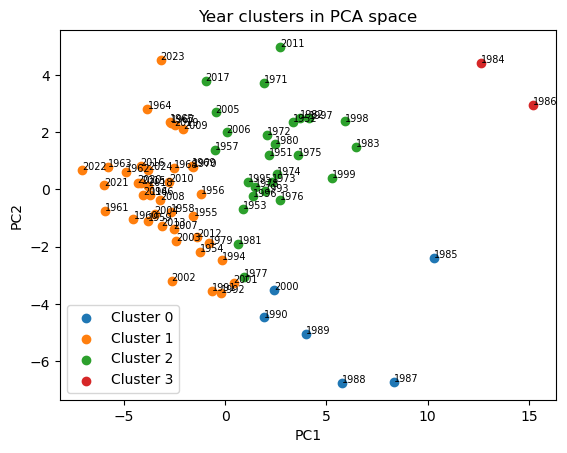

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot, coloring by cluster label
fig, ax = plt.subplots()

for cluster_id in range(4):
    mask = kmeans.labels_ == cluster_id  # boolean mask for this cluster
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Cluster {cluster_id}")

# Annotate each point with its year
for i, year in enumerate(years):
    ax.annotate(str(year), (X_pca[i, 0], X_pca[i, 1]), fontsize=7)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Year clusters in PCA space")
ax.legend()
plt.show()

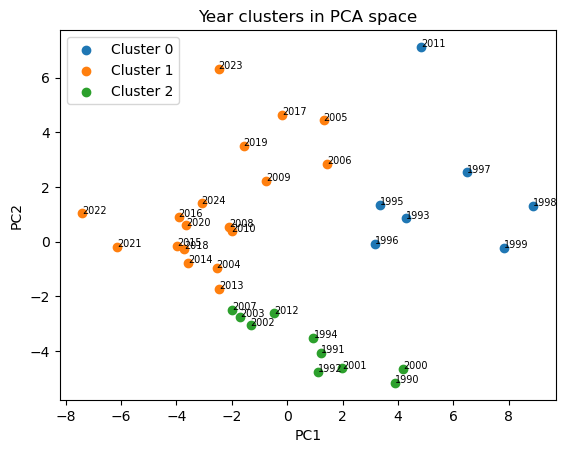

(35, 60)

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

years = list(yearly_vectors_snowpack.keys())    
X = np.array(list(yearly_vectors_snowpack.values()))

nbrs = NearestNeighbors(n_neighbors=10, metric='euclidean')
nbrs.fit(X)

distances, indices = nbrs.kneighbors(X)  # query all rows at once

for i, year in enumerate(years):
    neighbor_years = [years[j] for j in indices[i][1:]]  # skip self at index 0
    # print(f"{year}: nearest neighbors → {neighbor_years}")

kmeans = KMeans(n_clusters=3)  # try a few values
kmeans.fit(X)

for year, label in zip(years, kmeans.labels_):
    # print(f"{year}: cluster {label}")
    pass

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot, coloring by cluster label
fig, ax = plt.subplots()

for cluster_id in range(3):
    mask = kmeans.labels_ == cluster_id  # boolean mask for this cluster
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Cluster {cluster_id}")

# Annotate each point with its year
for i, year in enumerate(years):
    ax.annotate(str(year), (X_pca[i, 0], X_pca[i, 1]), fontsize=7)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Year clusters in PCA space")
ax.legend()
plt.show()
X.shape

In [14]:
# functional PCA ?

1951: nearest neighbors → [1972]
1952: nearest neighbors → [1976]
1953: nearest neighbors → [1996]
1954: nearest neighbors → [1955]
1955: nearest neighbors → [2012]
1956: nearest neighbors → [1955]
1957: nearest neighbors → [2005]
1958: nearest neighbors → [1966]
1959: nearest neighbors → [2014]
1960: nearest neighbors → [1961]
1961: nearest neighbors → [1960]
1962: nearest neighbors → [1963]
1963: nearest neighbors → [1961]
1964: nearest neighbors → [1967]
1965: nearest neighbors → [1967]
1966: nearest neighbors → [2018]
1967: nearest neighbors → [2009]
1968: nearest neighbors → [2010]
1969: nearest neighbors → [1955]
1970: nearest neighbors → [1955]
1971: nearest neighbors → [1997]
1972: nearest neighbors → [1974]
1973: nearest neighbors → [1978]
1974: nearest neighbors → [1972]
1975: nearest neighbors → [1995]
1976: nearest neighbors → [1974]
1977: nearest neighbors → [1981]
1978: nearest neighbors → [1996]
1979: nearest neighbors → [2012]
1980: nearest neighbors → [1993]
1981: near

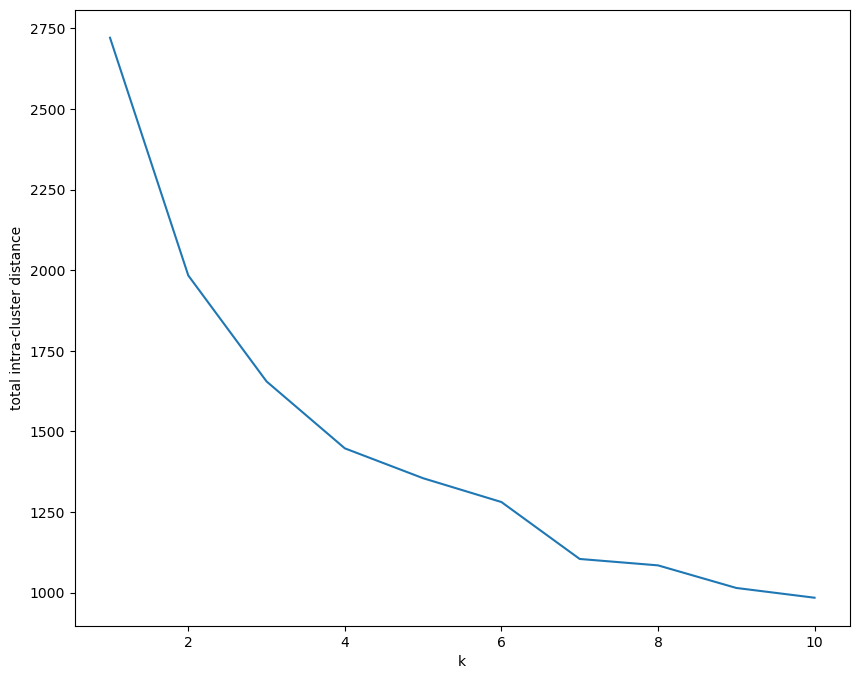

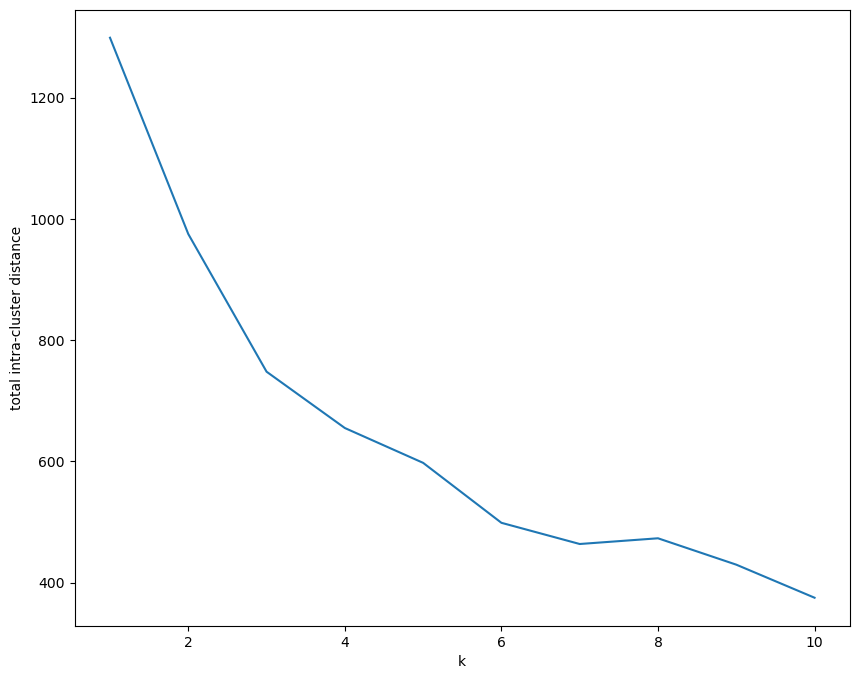

In [15]:
## Adding in the KMeans forcast analysis and checks for best value of k ##

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans

years = list(yearly_vectors_nosnow.keys())    
X_ns = np.array(list(yearly_vectors_nosnow.values()))
X_snow = np.array(list(yearly_vectors_snowpack.values()))

nbrs = NearestNeighbors(n_neighbors=2, metric='euclidean')
nbrs.fit(X_ns)

distances, indices = nbrs.kneighbors(X_ns)  # query all rows at once

for i, year in enumerate(years):
    neighbor_years = [years[j] for j in indices[i][1:]]  # skip self at index 0
    print(f"{year}: nearest neighbors → {neighbor_years}")

# Determine a good k for KMeans by looking at the elbow method
k_vals = range(1,11)
scores_no_snow = []
scores_snow = []

for k in k_vals:
    model_ns = KMeans(n_clusters=k, random_state=33)
    model_snow = KMeans(n_clusters=k, random_state=33)
    y_pred_ns = model_ns.fit_predict(X_ns)
    y_pred_snow = model_snow.fit_predict(X_snow)
    scores_no_snow.append(-model_ns.score(X_ns))
    scores_snow.append(-model_snow.score(X_snow))

fig = plt.figure(figsize=(10, 8))
plt.plot(k_vals, scores_no_snow)
plt.ylabel('total intra-cluster distance')
plt.xlabel('k')
plt.show()

fig2 = plt.figure(figsize=(10, 8))
plt.plot(k_vals, scores_snow)
plt.ylabel('total intra-cluster distance')
plt.xlabel('k')
plt.show()

# Best educated guess is 4 clusters for both datasets based on the elbow method

Analog distances: [0.08168613 0.38223144 0.43954529 0.45684676]
Sampling probabilities: [0.63356869 0.13540035 0.11774506 0.11328589]
Analog distances: [0.35681602 0.36852433 0.46230182 0.56659602]
Sampling probabilities: [0.29675271 0.28732467 0.22904126 0.18688136]
Analog distances: [0.28668121 0.3290642  0.44395319 0.44433268]
Sampling probabilities: [0.31624105 0.27550978 0.20421179 0.20403738]
Analog distances: [0.25886074 0.34854234 0.45686642 0.52401306]
Sampling probabilities: [0.35672306 0.26493678 0.2021198  0.17622037]
Analog distances: [0.33159901 0.82029159 0.87439183 1.17389413]
Sampling probabilities: [0.48403671 0.19566991 0.18356347 0.13672991]
Analog distances: [0.5105561  0.60633947 0.63455841 0.73204079]
Sampling probabilities: [0.29903787 0.25179897 0.24060143 0.20856173]
Analog distances: [0.08611302 0.32387316 0.47437369 0.56551553]
Sampling probabilities: [0.6251196  0.16621134 0.11347899 0.09519007]
Analog distances: [0.34761536 0.53175665 0.6399759  0.66471468

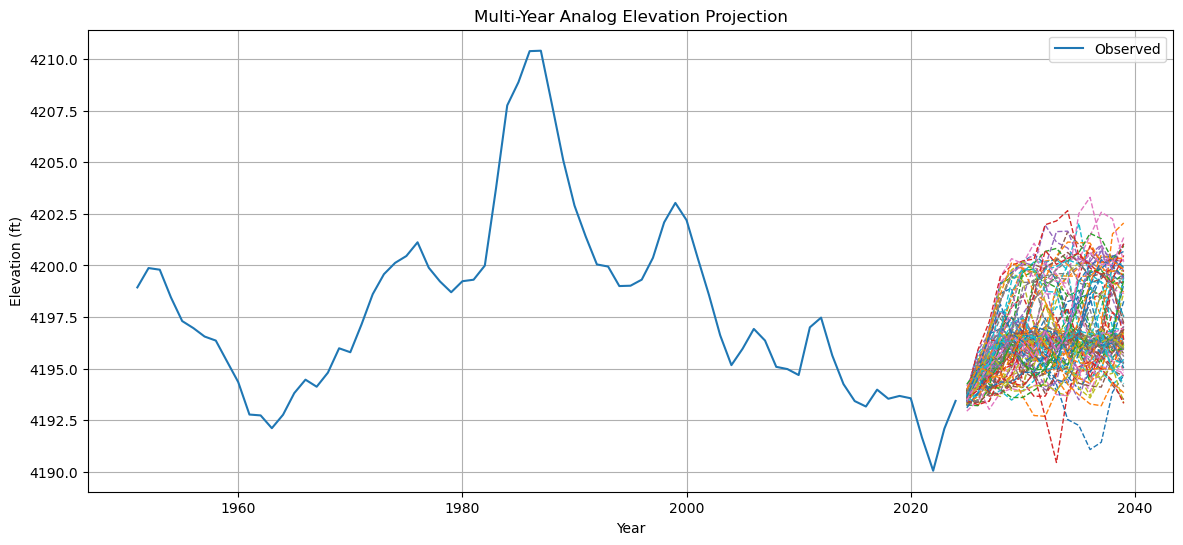

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

df = gsl_monthly_nosnow.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

years_to_simulate = 15 # number of years to simulate into the future
n_analogs = 4 # number of nearest neighbors to consider as analogs
n_blend = 3 # number of analogs to blend together for each step
noise_scale = 0.03 # 3% of the standard deviation of each feature

state_features = [
    # "snow_water_equiv_in",
    "precip_acft",
    "total_inflow_cfs_acft",
    "evaporation_acft",
    "elevation_ft"
]

## Create the yearly states ##
year_features = (
    df.groupby("year").agg({
            # "snow_water_equiv_in": "mean",
            "precip_acft": "sum",
            "total_inflow_cfs_acft": "sum",
            "evaporation_acft": "sum",
            "elevation_ft": "mean"
        })
        .dropna()
)

current_year = year_features.index.max()
initial_state = year_features.loc[[current_year]].copy()

prediction_dfs = []

for i in range(101):

    # Reset the start state for each simulation run
    current_state = initial_state.copy()

    future_trajectory = []
    historical_states = year_features.iloc[:-1].copy()

    for step in range(years_to_simulate):

        # Scale historical states for KNN
        scaler = StandardScaler()
        X_hist = scaler.fit_transform(historical_states)

        # Fit KNN on historical states
        knn = NearestNeighbors(n_neighbors=n_analogs)
        knn.fit(X_hist)

        # Scale the current state using the same scaler
        X_target = scaler.transform(current_state)

        # Get indices of nearest neighbors
        distances, indices = knn.kneighbors(X_target)

        # Get the years corresponding to the nearest neighbors
        analog_years = historical_states.index[indices[0]]
        analog_distances = distances[0]
        print("Analog distances:", analog_distances)

        # chosen_analog = np.random.choice(analog_years, k=2)

        ## Use distance-weighted sampling ##
        weights = 1 / (analog_distances + 1e-6)
        probabilities = weights / weights.sum()
        print("Sampling probabilities:", probabilities)

        # Use the weighted probabilities to randomly select analog years to blend together
        chosen_years = np.random.choice(
            analog_years,
            size=n_blend,
            replace=False,
            p=probabilities
        )

        # Generate random blend weights from a Dirichlet distribution to ensure they sum to 1
        blend_weights = np.random.dirichlet(np.ones(n_blend))

        states = []

        # For each chosen analog year, get the next year's state and weight it by the blend weight
        for yr, w in zip(chosen_years, blend_weights):

            next_year = yr + 1
            if next_year not in year_features.index:
                continue

            states.append(year_features.loc[next_year] * w)

        if len(states) == 0:
            break

        # Blend the states together to get the next state and add random noise to introduce variability
        next_state = pd.DataFrame([sum(states)])
        random_noise = np.random.normal(0, noise_scale * year_features.std(), size=next_state.shape)
        next_state += random_noise
        next_state.index = [current_year + step + 1]
        future_trajectory.append(next_state)

        # Advance the simulation state
        current_state = next_state

    # Combine the future trajectory into a single dataframe and add year and date columns for plotting
    future_df = pd.concat(future_trajectory)
    final_df = future_df.copy()
    final_df["year"] = final_df.index
    final_df["date"] = pd.to_datetime(
        {
            "year": final_df["year"],
            "month": 1,
            "day": 1
        }
    )

    # Store the final dataframe for this simulation run in the list of predictions
    prediction_dfs.append(final_df)

# Plot historical elevation and future projection
plt.figure(figsize=(14,6))

# Create a historical yearly aggregated dataframe for plotting
yearly_historical_data = (
        df.groupby("year")
        .agg({
            # "snow_water_equiv_in": "mean",
            "precip_acft": "sum",
            "total_inflow_cfs_acft": "sum",
            "evaporation_acft": "sum",
            "elevation_ft": "mean"
        })
        .dropna()
)

yearly_historical_data["year"] = yearly_historical_data.index

# Plot historical elevation
plt.plot(
    yearly_historical_data["year"],
    yearly_historical_data["elevation_ft"],
    label="Observed"
)

# Plot future projections for elevation
for prediction in prediction_dfs:
    plt.plot(
        prediction["year"],
        prediction["elevation_ft"],
        "--",
        linewidth=1
    )

plt.legend()
plt.grid(True)
plt.title("Multi-Year Analog Elevation Projection")
plt.xlabel("Year")
plt.ylabel("Elevation (ft)")
plt.show()


One really interesting insight from running this simulation is that the bulk of the simulation curves trend slighly upwards, then largely level off. This indicates that under historic variability alone, the lake levels could stabilize rather than continue to collapse. This makes sense because our data does not take into account the human factors which many other papers say is one of the biggest factors for lake level decline for the Great Salt Lake. If anything this plot shows that excluding all human factors, there could be a situation where lake levels slowly recover, but it is still unlikely that levels would reach a historic mean elevation.

Running this simulation confirms some of the information we saw in the PCA clustering above with more recent years clustering together. In the simulation, the vast majority of trajectories have a relatively flat pattern and are therefore close together and similar to more recent years in elevation. 